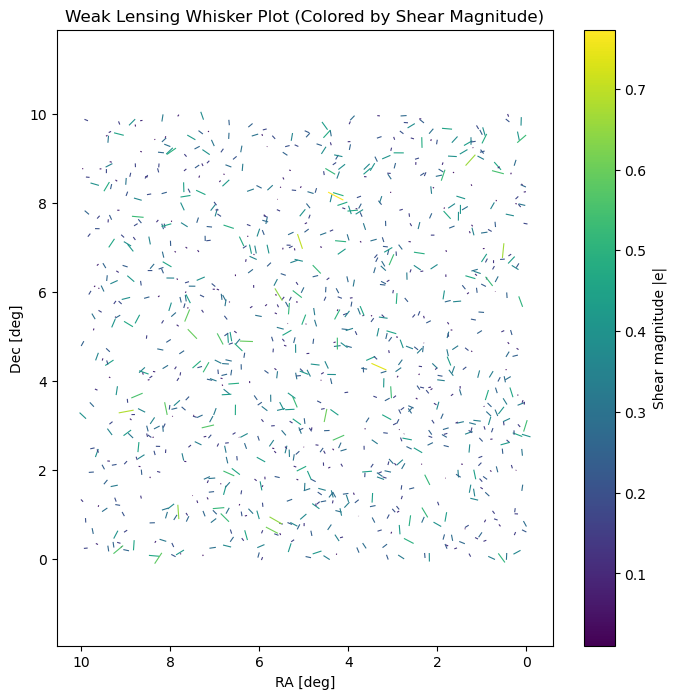

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic catalog
n_galaxies = 1000
ra = np.random.uniform(0, 10, n_galaxies)   # degrees
dec = np.random.uniform(0, 10, n_galaxies)
e1 = np.random.normal(0, 0.2, n_galaxies)
e2 = np.random.normal(0, 0.2, n_galaxies)

# Ellipticity magnitude and angle
ellipticity = np.sqrt(e1**2 + e2**2)
theta = 0.5 * np.arctan2(e2, e1)

# Line segment endpoints
scale = 0.5
dx = scale * ellipticity * np.cos(theta)
dy = scale * ellipticity * np.sin(theta)

x0 = ra - dx/2
x1 = ra + dx/2
y0 = dec - dy/2
y1 = dec + dy/2

# Build line segments
segments = [((x0[i], y0[i]), (x1[i], y1[i])) for i in range(n_galaxies)]

# Plot with colors representing shear magnitude
from matplotlib.collections import LineCollection
lc = LineCollection(segments, cmap='viridis', array=ellipticity,
                    linewidths=0.8)

plt.figure(figsize=(8, 8))
plt.gca().add_collection(lc)
plt.colorbar(lc, label="Shear magnitude |e|")
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Weak Lensing Whisker Plot (Colored by Shear Magnitude)")
plt.gca().invert_xaxis()
plt.axis("equal")
plt.show()